# MecâniQA — Entregável 2: Baseline e Métricas de Avaliação

**Disciplina:** Modelos de Aprendizado de Máquina
**Time:** Boa-vista
**Membros:** Alex Oliveira Santos, Alice Gomes Aragão, Ana Clara Ribeiro da Silva, Lorran Edley Matos Ribeiro, Rodrigo dos Anjos Lamartine
**Data de entrega:** 20/09/2026

## Contexto

Na OAT 1 (Entregável 1), o time de Ciência de Dados da MecâniQA validou a integridade da linha do tempo, tratou dados ausentes/outliers e construiu os primeiros modelos baseline (Naive e Médias Móveis).

Nesta OAT 2, o objetivo é dar continuidade a esse trabalho:

1. **Baseline avançado e protegido contra Data Leakage** — reconstruir os modelos Naive e Média Móvel garantindo que nenhuma previsão em `t` utilize informação de `t` ou `t+1`.
2. **Motor de avaliação** com MAE, RMSE e MAPE.
3. **Validação Temporal (TimeSeriesSplit)** — abandonar qualquer divisão aleatória e validar o baseline com cortes cronológicos.
4. **Feature Engineering Temporal** — criar Lags (1, 7, 30 dias) e uma Rolling Window como atributos permanentes do dataset, sem vazar informação futura.

> **Observação importante:** por exigência do enunciado ("o sistema deve evoluir a partir do dataset já limpo"), este notebook **reaplica o mesmo pipeline de limpeza construído na OAT 1** (tratamento de valores negativos/ausentes por interpolação temporal e tratamento de outliers por IQR) antes de qualquer modelagem. Todas as etapas abaixo — baselines, validação cruzada e features — operam sobre a série **já tratada**, nunca sobre o dataset bruto.

## 1. Importação das bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (14, 6)


## 2. Carregamento e limpeza do dataset (pipeline da OAT 1)

Reaplicamos exatamente o mesmo tratamento validado no Entregável 1:

1. Indexação temporal e frequência diária explícita (`asfreq("D")`).
2. Valores negativos em `Trocas_Oleo` e `Manutencao_Motor` são inválidos (erro de lançamento) → convertidos para `NaN`.
3. Preenchimento de ausências por **interpolação temporal** (`method="time"`).
4. Outliers estatísticos (método IQR) tratados por **clipping**, preservando a continuidade da série — sem isso, os baselines e as features herdariam os picos de digitação (ex.: 150 trocas de óleo em 15/02/2024) e distorceriam as métricas de erro.

In [2]:
df = pd.read_excel("mecaniqa_dataset.xlsx")
df["Data"] = pd.to_datetime(df["Data"])
df = df.set_index("Data").sort_index()
df = df.asfreq("D")

# Valores negativos são impossíveis para quantidades de serviços -> tratados como inválidos.
for coluna in ["Trocas_Oleo", "Manutencao_Motor"]:
    df.loc[df[coluna] < 0, coluna] = np.nan

# Interpolação temporal para ausências e valores inválidos.
for coluna in ["Trocas_Oleo", "Manutencao_Motor"]:
    df[coluna] = df[coluna].interpolate(method="time")


def detectar_outliers_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    return limite_inferior, limite_superior


df_model = df.copy()
for coluna in ["Trocas_Oleo", "Manutencao_Motor"]:
    limite_inferior, limite_superior = detectar_outliers_iqr(df_model[coluna])
    limite_inferior = max(0, limite_inferior)  # quantidade de serviços não pode ser negativa
    df_model[coluna] = df_model[coluna].clip(lower=limite_inferior, upper=limite_superior)

print("Formato do dataset limpo:", df_model.shape)
print("Valores ausentes após limpeza:")
print(df_model.isna().sum())
df_model.head()


Formato do dataset limpo: (731, 2)
Valores ausentes após limpeza:
Trocas_Oleo         0
Manutencao_Motor    0
dtype: int64


## 3. Modelos Baseline protegidos contra Data Leakage

**A Armadilha do Futuro (decisão da equipe, sessão 02/09):** ao calcular médias móveis ou preencher valores, é fácil deixar a previsão de hoje "enxergar" dados de amanhã. A defesa contra isso é sempre a mesma: **deslocar a série com `.shift(1)`** antes de qualquer cálculo ser usado como previsão.

- **Naive:** `serie.shift(1)` → a previsão do dia `t` é exatamente o valor real observado em `t-1`.
- **Média Móvel:** primeiro `.rolling(janela).mean()`, **depois** `.shift(1)`. Se o `shift` fosse aplicado antes do `rolling` (ou omitido), a janela em `t` incluiria o próprio valor do dia atual — vazamento de dados.

Por decisão da equipe, cada abordagem é uma **função pura**: recebe uma `pandas.Series` e devolve outra `Series` alinhada ao mesmo índice temporal, sem uso de classes ou abstrações de arquitetura.

In [3]:
def previsao_naive(serie: pd.Series) -> pd.Series:
    """Modelo ingênuo: a previsão do dia t é o valor real observado em t-1."""
    return serie.shift(1).rename("previsao_naive")


def previsao_media_movel(serie: pd.Series, janela: int = 7) -> pd.Series:
    """Média das últimas `janela` observações, deslocada 1 dia para frente.

    A ordem das operações é o que evita o vazamento de dados:
    1. rolling(janela).mean()  -> média usando os dias [t-janela+1, ..., t]
    2. shift(1)                -> desloca essa média para ser a previsão de t+1

    Assim, a previsão do dia t usa apenas dados até o dia t-1.
    """
    return (
        serie.rolling(window=janela, min_periods=janela)
        .mean()
        .shift(1)
        .rename(f"previsao_mm_{janela}d")
    )


## 4. QA — Validação anti-leakage

Critério de aceite da sessão 02/09: *"o QA deve atestar que nenhuma previsão no tempo t utilizou dados de t+1"*. A função abaixo reconstrói manualmente a previsão esperada e compara com a gerada pelas funções oficiais.

In [4]:
def qa_validar_sem_leakage(serie: pd.Series, naive: pd.Series, mm: pd.Series, janela: int = 7) -> bool:
    erros = []

    # 1) Naive: previsao[t] deve ser igual a serie[t-1]
    comparacao = naive.dropna()
    referencia = serie.shift(1).loc[comparacao.index]
    if not np.allclose(comparacao.values, referencia.values, equal_nan=True):
        erros.append("Naive: encontrada previsão que não corresponde a t-1.")

    if not naive.index.equals(serie.index):
        erros.append("Naive: índice temporal não corresponde à série original.")

    # 2) Média móvel: reconstrução manual usando apenas [t-janela, ..., t-1]
    serie_deslocada = serie.shift(1)
    mm_manual = serie_deslocada.rolling(window=janela, min_periods=janela).mean()
    diffs = (mm.dropna() - mm_manual.dropna()).abs()
    if not (diffs < 1e-9).all():
        erros.append("Média Móvel: valores não batem com a reconstrução manual sem t/t+1.")

    # 3) Checagem pontual: a janela usada na última previsão não inclui o dia atual
    idx_teste = mm.dropna().index[-1]
    pos = serie.index.get_loc(idx_teste)
    janela_usada = serie.iloc[pos - janela: pos]
    if not np.isclose(janela_usada.mean(), mm.loc[idx_teste]):
        erros.append("Média Móvel: a janela usada na previsão parece incluir o dia atual.")

    if erros:
        print("QA REPROVADO:")
        for e in erros:
            print(" -", e)
        return False

    print("QA APROVADO: nenhuma previsão em t utilizou dados de t ou t+1.")
    return True


for coluna in ["Trocas_Oleo", "Manutencao_Motor"]:
    print(f"--- {coluna} ---")
    naive_check = previsao_naive(df_model[coluna])
    mm_check = previsao_media_movel(df_model[coluna], janela=7)
    qa_validar_sem_leakage(df_model[coluna], naive_check, mm_check, janela=7)


--- Trocas_Oleo ---
QA APROVADO: nenhuma previsão em t utilizou dados de t ou t+1.
--- Manutencao_Motor ---
QA APROVADO: nenhuma previsão em t utilizou dados de t ou t+1.


## 5. Real x Previsões — verificação visual do deslocamento

Critério de aceite: *"o gráfico deve exibir claramente o deslocamento correto no tempo"*. Plotamos o histórico real sobreposto às previsões Naive e Média Móvel (7 dias), para as duas séries do negócio.

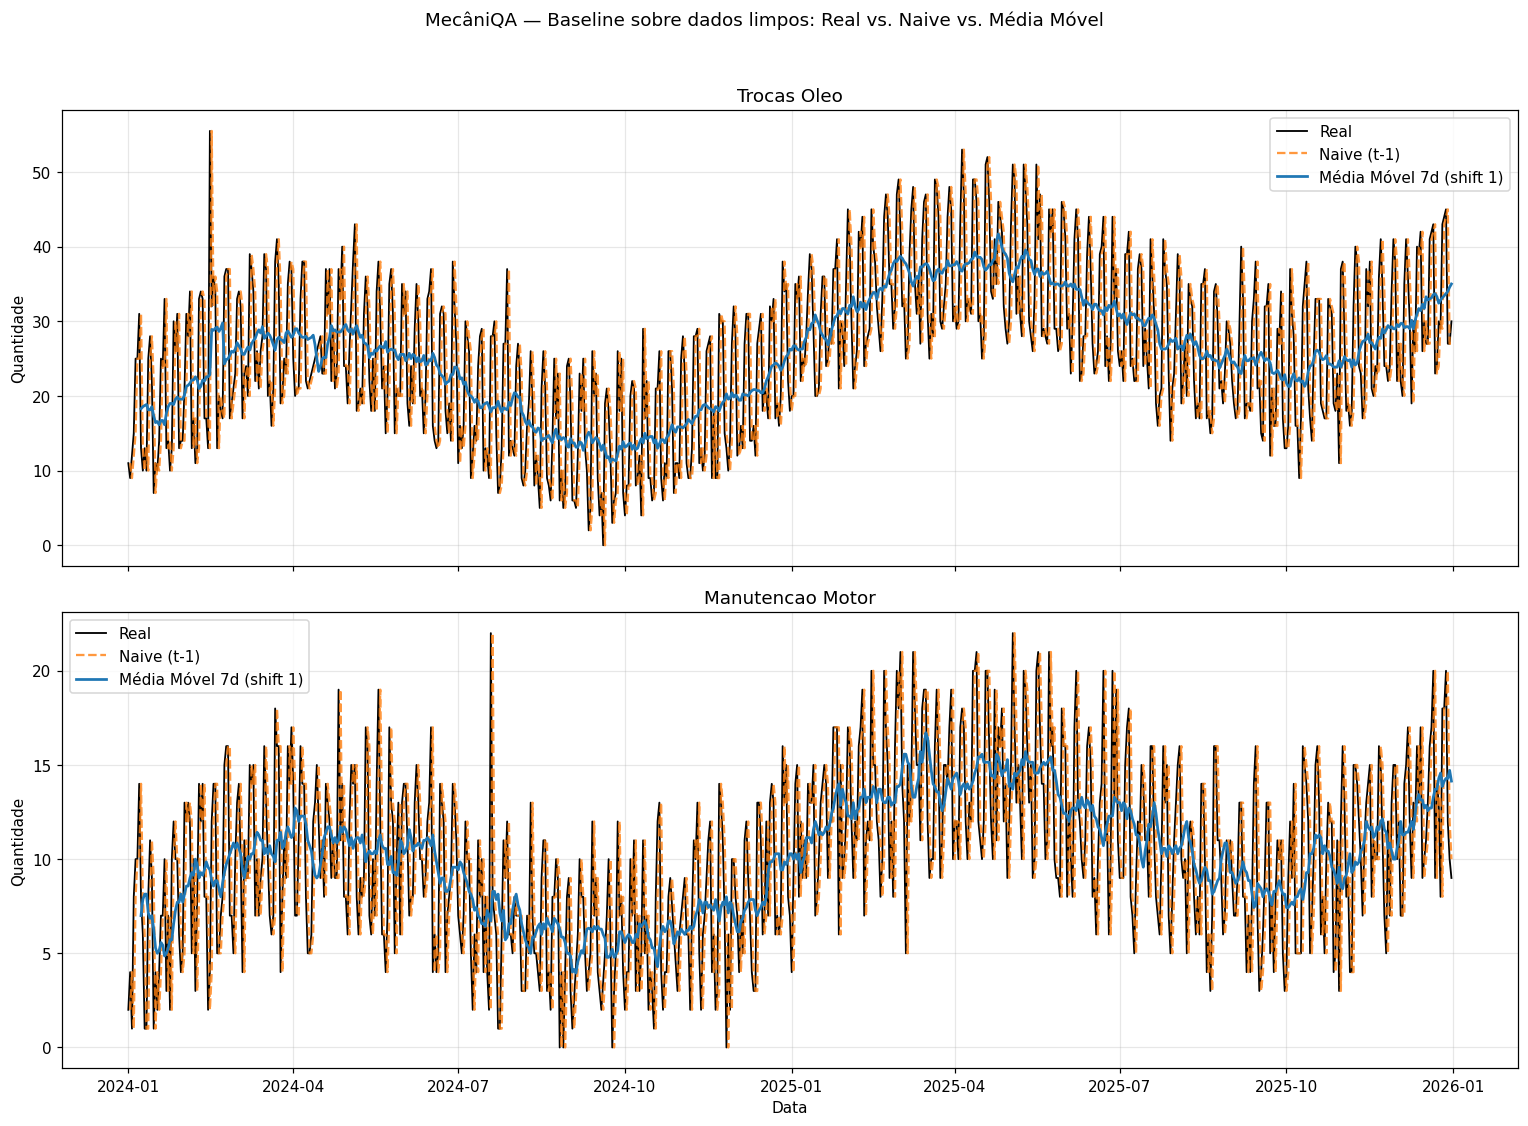

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for ax, coluna in zip(axes, ["Trocas_Oleo", "Manutencao_Motor"]):
    serie = df_model[coluna]
    naive = previsao_naive(serie)
    mm = previsao_media_movel(serie, janela=7)

    ax.plot(serie.index, serie.values, label="Real", color="black", linewidth=1.2)
    ax.plot(naive.index, naive.values, label="Naive (t-1)", color="tab:orange", linestyle="--", alpha=0.8)
    ax.plot(mm.index, mm.values, label="Média Móvel 7d (shift 1)", color="tab:blue", linewidth=1.8)
    ax.set_title(coluna.replace("_", " "))
    ax.set_ylabel("Quantidade")
    ax.legend()
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Data")
fig.suptitle("MecâniQA — Baseline sobre dados limpos: Real vs. Naive vs. Média Móvel", y=1.02)
fig.tight_layout()
plt.show()


## 6. Motor de Avaliação — MAE, RMSE e MAPE

- **MAE (Erro Absoluto Médio):** erro médio diário, em unidades reais (nº de trocas/manutenções) — fácil de explicar para o dono da oficina.
- **RMSE (Raiz do Erro Quadrático Médio):** penaliza mais os erros grandes; é a métrica que mais evidencia um pico fora da curva.
- **MAPE (Erro Percentual Absoluto Médio):** erro relativo, em %. Como a MAPE não é definida quando o valor real é zero, ela é calculada **apenas sobre os dias com demanda diferente de zero** — mas o **MAE e o RMSE continuam sendo calculados sobre todos os dias**, sem descartar nenhum, para não distorcer essas duas métricas.

In [6]:
def avaliar_metricas(y_real: pd.Series, y_previsto: pd.Series) -> dict:
    dados = pd.concat([y_real, y_previsto], axis=1).dropna()
    dados.columns = ["real", "previsto"]

    mae = mean_absolute_error(dados["real"], dados["previsto"])
    rmse = np.sqrt(mean_squared_error(dados["real"], dados["previsto"]))

    # MAPE só é calculado nos dias com valor real diferente de zero (evita divisão por zero),
    # mas isso NÃO afeta o cálculo do MAE/RMSE acima, que usam todos os dias válidos.
    dados_mape = dados[dados["real"] != 0]
    dias_excluidos_mape = len(dados) - len(dados_mape)
    if len(dados_mape) > 0:
        mape = mean_absolute_percentage_error(dados_mape["real"], dados_mape["previsto"]) * 100
    else:
        mape = np.nan

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "n_dias": len(dados), "dias_excluidos_mape": dias_excluidos_mape}


## 7. Validação Temporal (TimeSeriesSplit)

**Por que não K-Fold clássico (decisão da equipe, sessão 09/09):** o K-Fold tradicional embaralha os dados aleatoriamente, quebrando a ordem cronológica — o modelo acabaria "treinando" com dias do futuro para prever o passado. O `TimeSeriesSplit` respeita a linha do tempo: cada corte de teste vem sempre **depois** do corte de treino correspondente.

**Como isso é usado aqui:** as previsões Naive e Média Móvel não têm parâmetros a "treinar" — são funções de janela deslizante que já olham apenas para o passado por construção (seção 3). Por isso, calculamos a previsão **uma única vez sobre a série completa** e usamos os índices de teste de cada fold do `TimeSeriesSplit` apenas para **recortar honestamente os blocos cronológicos de avaliação** (o índice de treino de cada fold delimita o corte, garantindo que nenhum bloco de teste seja avaliado usando um período anterior ao que seria "conhecido" naquele fold). Isso evita o erro do protótipo anterior, em que a previsão era recalculada *dentro* de cada fatia de teste — o que zerava a janela no início de cada fold e não representava, de fato, uma validação temporal.

In [7]:
def validar_time_series_split(serie: pd.Series, previsao: pd.Series, n_splits: int = 5) -> pd.DataFrame:
    tscv = TimeSeriesSplit(n_splits=n_splits)
    linhas = []

    for fold, (idx_treino, idx_teste) in enumerate(tscv.split(serie), start=1):
        y_real_fold = serie.iloc[idx_teste]
        y_previsto_fold = previsao.iloc[idx_teste]
        metricas = avaliar_metricas(y_real_fold, y_previsto_fold)
        metricas["fold"] = fold
        metricas["periodo_teste"] = f"{y_real_fold.index.min().date()} a {y_real_fold.index.max().date()}"
        linhas.append(metricas)

    colunas = ["fold", "periodo_teste", "n_dias", "MAE", "RMSE", "MAPE", "dias_excluidos_mape"]
    return pd.DataFrame(linhas)[colunas]


N_SPLITS = 5
JANELA = 7
resultados_finais = {}

for coluna in ["Trocas_Oleo", "Manutencao_Motor"]:
    serie = df_model[coluna]
    previsao_naive_serie = previsao_naive(serie)
    previsao_mm_serie = previsao_media_movel(serie, JANELA)

    print(f"\n{'=' * 70}")
    print(f"=== {coluna} — Validação Temporal (TimeSeriesSplit, {N_SPLITS} folds) ===")
    print(f"{'=' * 70}")

    resultado_naive = validar_time_series_split(serie, previsao_naive_serie, N_SPLITS)
    resultado_mm = validar_time_series_split(serie, previsao_mm_serie, N_SPLITS)

    mae_n, rmse_n, mape_n = resultado_naive[["MAE", "RMSE", "MAPE"]].mean()
    mae_m, rmse_m, mape_m = resultado_mm[["MAE", "RMSE", "MAPE"]].mean()

    print("\nModelo Naive — por fold:")
    print(resultado_naive.to_string(index=False))
    print(f"\nResultados do Baseline - MAE: {mae_n:.2f}, RMSE: {rmse_n:.2f}, MAPE: {mape_n:.2f}%")

    print(f"\nModelo Média Móvel {JANELA}d — por fold:")
    print(resultado_mm.to_string(index=False))
    print(f"\nResultados do Baseline - MAE: {mae_m:.2f}, RMSE: {rmse_m:.2f}, MAPE: {mape_m:.2f}%")

    melhor = "Naive" if mae_n < mae_m else f"Média Móvel {JANELA}d"
    print(f"\n>>> Melhor baseline (menor MAE) para {coluna}: {melhor}")

    resultados_finais[coluna] = {
        "Naive": {"MAE": mae_n, "RMSE": rmse_n, "MAPE": mape_n},
        f"Média Móvel {JANELA}d": {"MAE": mae_m, "RMSE": rmse_m, "MAPE": mape_m},
        "melhor": melhor,
    }



=== Trocas_Oleo — Validação Temporal (TimeSeriesSplit, 5 folds) ===

Modelo Naive — por fold:
 fold           periodo_teste  n_dias      MAE     RMSE      MAPE  dias_excluidos_mape
    1 2024-05-06 a 2024-09-03     121 6.867769 9.074986 42.549639                    0
    2 2024-09-04 a 2025-01-02     121 6.611570 9.074531 51.021833                    1
    3 2025-01-03 a 2025-05-03     121 6.371901 8.333444 18.954565                    0
    4 2025-05-04 a 2025-09-01     121 6.702479 9.027506 23.104419                    0
    5 2025-09-02 a 2025-12-31     121 6.677686 9.081814 27.582173                    0

Resultados do Baseline - MAE: 6.65, RMSE: 8.92, MAPE: 32.64%

Modelo Média Móvel 7d — por fold:
 fold           periodo_teste  n_dias      MAE     RMSE      MAPE  dias_excluidos_mape
    1 2024-05-06 a 2024-09-03     121 7.402597 8.063084 47.786865                    0
    2 2024-09-04 a 2025-01-02     121 7.391972 8.037513 59.762993                    1
    3 2025-01-03 a 2025-0

### 7.1 Comparativo consolidado

In [8]:
comparativo = []
for coluna, res in resultados_finais.items():
    for modelo in ["Naive", f"Média Móvel {JANELA}d"]:
        linha = {"Variável": coluna, "Modelo": modelo, **res[modelo]}
        comparativo.append(linha)

df_comparativo = pd.DataFrame(comparativo)
df_comparativo


## 8. Feature Engineering Temporal — Lags e Rolling Window

**Escolha dos lags (decisão da equipe, sessão 16/09):**
- **Lag 1:** captura a inércia mais básica — o que aconteceu ontem tende a se repetir hoje.
- **Lag 7:** o mais relevante para o negócio, pois a oficina tem dinâmica semanal clara (dias úteis x fim de semana); puxa o valor do **mesmo dia da semana** anterior.
- **Lag 30:** captura uma tendência de prazo mais longo (padrão mensal), sem custar informação recente demais.

**Tratamento dos NaNs no topo (decisão da equipe):** como o Lag 30 é o mais "caro" (gera as primeiras 30 linhas sem dado), optamos por **descartar (`dropna()`)** essas linhas em vez de preencher com médias/zeros — preencher seria inventar um dado que nunca existiu. Como o dataset tem 731 dias, perder os 30 primeiros é uma perda aceitável.

Também criamos uma **Rolling Window** (média móvel de 7 dias, já deslocada) como atributo permanente do dataset, com o mesmo cuidado anti-leakage da seção 3: o `.shift(1)` garante que o valor do dia `t` não inclua o próprio dia `t`.

As features são criadas para **as duas variáveis do negócio** (Trocas de Óleo e Manutenção de Motor), já que ambas alimentarão os futuros modelos de Machine Learning.

In [9]:
def criar_lags(df_entrada: pd.DataFrame, colunas: list, lags: list) -> pd.DataFrame:
    saida = df_entrada.copy()
    for coluna in colunas:
        for lag in lags:
            saida[f"{coluna}_lag_{lag}"] = saida[coluna].shift(lag)
    return saida


def criar_rolling_feature(df_entrada: pd.DataFrame, colunas: list, janela: int) -> pd.DataFrame:
    saida = df_entrada.copy()
    for coluna in colunas:
        # shift(1) garante que a média da janela em t não inclua o próprio dia t (sem vazamento).
        saida[f"{coluna}_rolling_mean_{janela}"] = (
            saida[coluna].rolling(window=janela, min_periods=janela).mean().shift(1)
        )
    return saida


COLUNAS_FEATURE = ["Trocas_Oleo", "Manutencao_Motor"]
LAGS = [1, 7, 30]
JANELA_ROLLING = 7

df_features = criar_lags(df_model, COLUNAS_FEATURE, LAGS)
df_features = criar_rolling_feature(df_features, COLUNAS_FEATURE, JANELA_ROLLING)

linhas_antes = len(df_features)
df_features_final = df_features.dropna()
linhas_depois = len(df_features_final)

print(f"Linhas antes da limpeza dos NaNs de lag: {linhas_antes}")
print(f"Linhas removidas (NaN gerado pelo Lag 30 no topo da série): {linhas_antes - linhas_depois}")
print(f"Linhas finais no dataset de features: {linhas_depois}")


Linhas antes da limpeza dos NaNs de lag: 731
Linhas removidas (NaN gerado pelo Lag 30 no topo da série): 30
Linhas finais no dataset de features: 701


### 8.1 Validação QA — `df.head(15)`

Critério de aceite: *"o QA deve testar e validar o DataFrame utilizando `.head(15)` para garantir que as features temporais estão preenchidas e alinhadas cronologicamente"*.

In [10]:
df_features_final.head(15)


## 9. Conclusão

- **Pipeline de limpeza da OAT 1 reaplicado** como ponto de partida obrigatório: os baselines e as features desta OAT 2 rodam sobre a série já tratada (sem os picos de digitação nem os valores negativos), evitando métricas infladas por sujeira de dados.
- **Baselines Naive e Média Móvel (7 dias)** implementados como funções puras, com QA automatizado confirmando ausência de Data Leakage (nenhuma previsão em `t` usa dados de `t` ou `t+1`).
- **Motor de avaliação** com MAE, RMSE e MAPE, com o MAPE isolado apenas para os dias com demanda diferente de zero, sem afetar o cálculo de MAE/RMSE.
- **TimeSeriesSplit (5 folds)** substituiu qualquer divisão aleatória: a previsão é calculada uma única vez sobre a série completa e avaliada apenas nos blocos de teste cronológicos de cada fold.
- Resultado consolidado: para **Trocas de Óleo**, o baseline **Naive** teve o menor MAE; para **Manutenção de Motor**, a **Média Móvel de 7 dias** foi o melhor baseline. Esses valores (ver seção 7.1) são o novo piso de comparação para os próximos modelos de Machine Learning.
- **Feature Engineering** concluída: Lags (1, 7, 30) e Rolling Mean (7 dias) criados para as duas variáveis do negócio, com os 30 primeiros dias descartados por conterem `NaN` gerado pelo Lag 30 — decisão documentada e mais honesta do que preencher artificialmente esses valores.

**Próximos passos:** usar `df_features_final` como base para treinar os primeiros modelos de Machine Learning supervisionado, comparando-os contra o piso estabelecido pelos baselines Naive e Média Móvel.